In [1]:
#pip install pandas numpy scikit-learn matplotlib fairlearn

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt

from fairlearn.metrics import MetricFrame
from fairlearn.metrics import selection_rate

In [3]:
df = pd.read_csv("../data/adult.csv")

In [4]:
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [5]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'educational-num',
       'marital-status', 'occupation', 'relationship', 'race', 'gender',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

In [6]:
df.isnull().sum()

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

In [7]:
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

In [10]:
df["gender"].value_counts()

gender
Male      32650
Female    16192
Name: count, dtype: int64

In [9]:
print(df.columns.tolist())

['age', 'workclass', 'fnlwgt', 'education', 'educational-num', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']


In [12]:
gender_data = df["gender"]

In [13]:
encoder = LabelEncoder()

for column in df.columns:
    if df[column].dtype == "object":
        df[column] = encoder.fit_transform(df[column])

In [14]:
X = df.drop("income", axis=1)

y = df["income"]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
model = RandomForestClassifier()

model.fit(X_train, y_train)

RandomForestClassifier()

In [17]:
predictions = model.predict(X_test)

In [18]:
accuracy = accuracy_score(y_test, predictions)

print(accuracy)

0.8641621455624936


In [19]:
gender_test = gender_data.loc[X_test.index]

In [20]:
metrics = {
    "selection_rate": selection_rate
}

fairness = MetricFrame(
    metrics=metrics,
    y_true=y_test,
    y_pred=predictions,
    sensitive_features=gender_test
)

fairness.by_group

,selection_rate
gender,
Female,0.077655
Male,0.266319


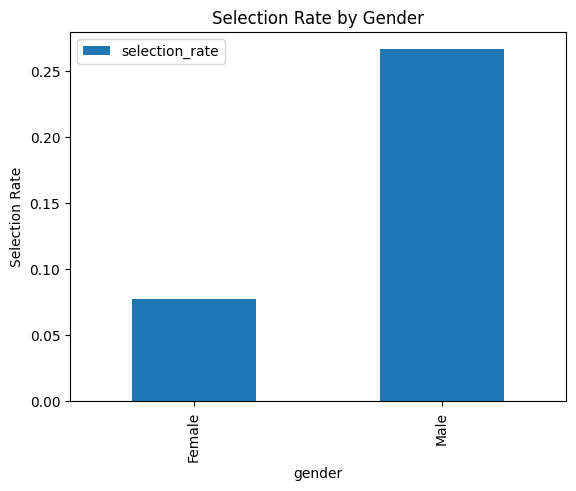

In [21]:
fairness.by_group.plot(kind="bar")

plt.title("Selection Rate by Gender")

plt.ylabel("Selection Rate")

plt.show()

In [22]:
results = fairness.by_group.reset_index()

results.to_csv("../outputs/fairness_results.csv", index=False)